# Module 10 — Regression Models
## Linear Regression · Cost Function · Gradient Descent · Logistic Regression
---
> এই module-এ ML-এর সবচেয়ে fundamental model — **Linear Regression** শেখা হবে।
> Linear Regression বোঝা মানে ML-এর core mathematics বোঝা।
> এর উপর দাঁড়িয়েই পরে Neural Network, Deep Learning সব বোঝা যাবে।

| Section | Topic |
|---|---|
| 10.1 | Introduction |
| 10.2 | Regression concept ও Best Line Fitting |
| 10.3 | Linear Regression Hands-on |
| 10.4 | Cost Function ও Gradient Descent |
| 10.5 | Cost Function ও Gradient Descent Hands-on |
| 10.6 | Regression Evaluation Metrics |
| 10.7 | Evaluation Metrics Hands-on |
| 10.8 | Assumptions ও Limitations |
| 10.9 | Logistic Regression ও Sigmoid Function |
| 10.10 | Conclusion |


---
## 10.1 Introduction

### Regression কী?
> **Regression** = একটি continuous numeric value predict করা।

**Classification vs Regression:**
```
Classification:  output = category
  -> Fraud / Not Fraud
  -> Cat / Dog
  -> Spam / Not Spam

Regression:      output = number
  -> House price = $245,000
  -> Temperature = 32.5 degree C
  -> Salary = 85,000 USD
```

### এই Module-এ কী শিখব?
- **Linear Regression**: সরল রেখা দিয়ে prediction
- **Cost Function**: model কতটা ভুল করছে তার measure
- **Gradient Descent**: ভুল কমানোর optimization algorithm
- **Evaluation Metrics**: R², MAE, RMSE
- **Logistic Regression**: Classification-এর জন্য Regression-এর extension

### কেন Linear Regression এত গুরুত্বপূর্ণ?
> Linear Regression-এর mathematics বুঝলে:
> Neural Network-এ প্রতিটি neuron = Linear Regression
> Gradient Descent = সব Deep Learning-এর backbone
> Cost Function = সব model optimization-এর ভিত্তি

### 🎯 Interview Topics
- Regression vs Classification মূল পার্থক্য?
  - Regression: continuous output (number), Classification: discrete output (class)
- Logistic Regression কি Regression নাকি Classification?
  - নামে Regression কিন্তু কাজে **Classification** — output probability (0-1)


In [1]:
# Now we import all required libraries for this module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")
plt.style.use("default")
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


> 📝 **এই code-এ কী হচ্ছে:** সব দরকারি library import করা হয়েছে। `np.random.seed(42)` দিলে random number সবসময় same আসে — reproducibility।

---
## 10.2 Regression Concept ও Best Line Fitting

### Simple Linear Regression
> একটি independent variable (X) দিয়ে একটি dependent variable (y) predict করা।

**Mathematical Formula:**
$$y = mx + b$$

অথবা ML notation-এ:
$$\hat{y} = w_1 x + w_0$$

| Symbol | মানে |
|---|---|
| $\hat{y}$ | Predicted value (আমরা যা predict করছি) |
| $x$ | Input feature (independent variable) |
| $w_1$ | Weight বা slope (রেখার ঢাল) |
| $w_0$ | Bias বা intercept (রেখা y-axis কোথায় কাটে) |

### Multiple Linear Regression
$$\hat{y} = w_1 x_1 + w_2 x_2 + ... + w_n x_n + w_0$$

### Best Line Fitting কী?
> সব data point-এর কাছ দিয়ে এমন একটি line আঁকা যেটার prediction error সবচেয়ে কম।

```
        y
        |    .  . 
        |   /  . .
        |  / .    .
        | / .   .
        |/_________ x
        
  এই / line-টাই Best Fit Line
  প্রতিটি dot = একটি data point
  dot থেকে line-এর দূরত্ব = error (residual)
```

### Slope ও Intercept-এর ব্যাখ্যা
- **Slope (w₁)**: X এক unit বাড়লে y কতটুকু বাড়ে/কমে
- **Intercept (w₀)**: X = 0 হলে y-এর predicted value

**উদাহরণ:** `Salary = 500 * Experience + 30000`
- Slope = 500: ১ বছর experience বাড়লে salary $500 বাড়ে
- Intercept = 30000: 0 বছর experience-এ salary $30,000

### 🎯 Interview Topics
- Best fit line কীভাবে বের করা হয়? → OLS (Ordinary Least Squares) method
- OLS কী minimize করে? → Sum of Squared Residuals (SSR)
- Residual কী? → Actual value - Predicted value = $y - \hat{y}$
- কেন squared error? → Negative error-কে positive করতে, large error-কে বেশি penalize করতে
- Normal Equation কী? → $w = (X^TX)^{-1}X^Ty$ — closed-form solution


In [24]:
# Now we create a simple dataset to visualize regression concept

# Simulate: Study Hours vs Exam Score
np.random.seed(42)
number_of_students = 50

study_hours = np.random.uniform(1, 10, number_of_students)
exam_scores = 7 * study_hours + 30 + np.random.normal(0, 5, number_of_students)

# Now we create a DataFrame
student_dataframe = pd.DataFrame({
    "Study Hours": study_hours,
    "Exam Score": exam_scores
})

print("First 10 rows of student data:")
print(student_dataframe.head(10))
print()

print("Basic statistics:")
print(student_dataframe.describe().round(2))

First 10 rows of student data:
   Study Hours  Exam Score
0     4.370861   64.288360
1     9.556429   97.751843
2     7.587945   82.537377
3     6.387926   73.209966
4     2.404168   39.436564
5     2.403951   43.228434
6     1.522753   38.356074
7     8.795585   96.854708
8     6.410035   76.588337
9     7.372653   72.793372

Basic statistics:
       Study Hours  Exam Score
count        50.00       50.00
mean          5.01       65.08
std           2.60       18.45
min           1.19       36.70
25%           2.65       50.21
50%           4.92       65.08
75%           6.85       76.50
max           9.73      104.60


> 📝 **এই code-এ কী হচ্ছে:** Study Hours vs Exam Score-এর synthetic dataset তৈরি করা হয়েছে। True relationship: Score = 7 * Hours + 30 + noise। Model-কে এই relationship শিখতে হবে data দেখে।

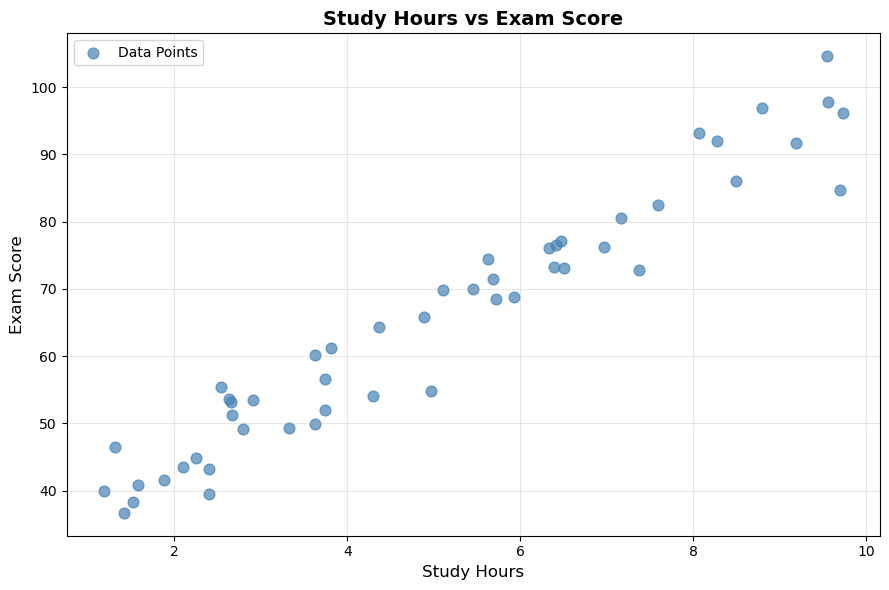

In [3]:
# Now we visualize the data as scatter plot

plt.figure(figsize=(9, 6))
plt.scatter(
    student_dataframe["Study Hours"],
    student_dataframe["Exam Score"],
    color="steelblue", alpha=0.7, s=60, label="Data Points"
)
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.title("Study Hours vs Exam Score", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Scatter plot দেখানো হয়েছে। প্রতিটি dot একজন student। X-axis = study hours, Y-axis = exam score।

> ### এই chart কীভাবে observe করব
> - প্রতিটি dot = একজন student-এর (study hours, exam score) pair।
> - Dots-এর pattern দেখো — উপরে-ডানে যাচ্ছে কিনা।

> ### এই chart থেকে কী observe করলাম
> - Study hours বাড়লে exam score বাড়ে — positive linear relationship স্পষ্ট।
> - কিছু scatter (noise) আছে — real data-তে এটাই স্বাভাবিক।

> ### Decision
> এই data-তে Linear Regression ভালো কাজ করবে কারণ clear linear trend আছে।


Best Fit Line: Score = 6.88 * Hours + 30.61
Slope (w1):     6.8759
Intercept (w0): 30.6076

True values used to generate data:
  True slope:     7.0
  True intercept: 30.0
Model learned close values -- great!


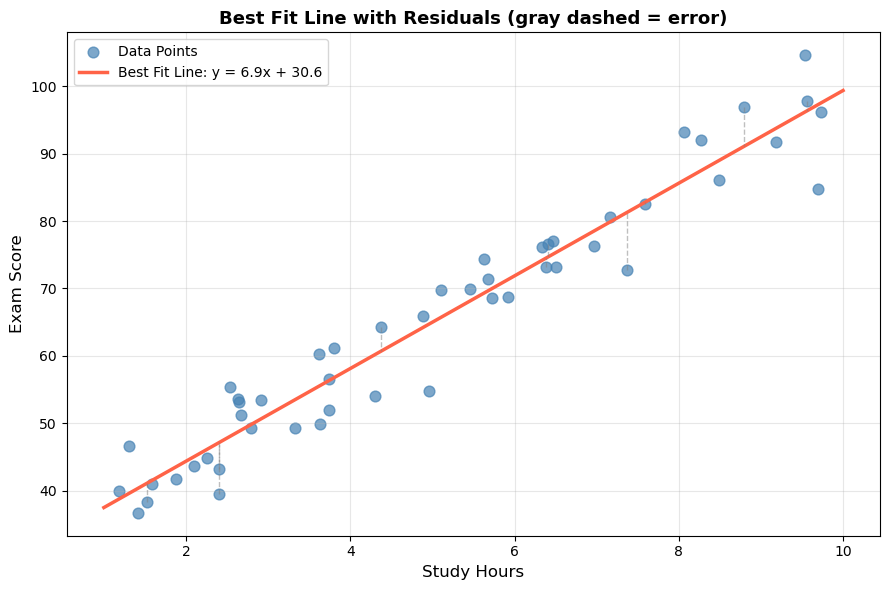

In [4]:
# Now we fit a regression line and visualize Best Fit Line

# Fit linear regression manually to get slope and intercept
X_hours = study_hours.reshape(-1, 1)
y_scores = exam_scores

linear_model = LinearRegression()
linear_model.fit(X_hours, y_scores)

slope = linear_model.coef_[0]
intercept = linear_model.intercept_

print(f"Best Fit Line: Score = {slope:.2f} * Hours + {intercept:.2f}")
print(f"Slope (w1):     {slope:.4f}")
print(f"Intercept (w0): {intercept:.4f}")
print()
print("True values used to generate data:")
print("  True slope:     7.0")
print("  True intercept: 30.0")
print("Model learned close values -- great!")

# Now we plot scatter + best fit line
x_line = np.linspace(1, 10, 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(9, 6))
plt.scatter(study_hours, exam_scores, color="steelblue", alpha=0.7, s=60, label="Data Points")
plt.plot(x_line, y_line, color="tomato", linewidth=2.5, label=f"Best Fit Line: y = {slope:.1f}x + {intercept:.1f}")

# Here we draw residuals for a few points
for i in range(0, 10):
    predicted = slope * study_hours[i] + intercept
    plt.plot([study_hours[i], study_hours[i]], [exam_scores[i], predicted],
             color="gray", linestyle="--", alpha=0.5, linewidth=1)

plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.title("Best Fit Line with Residuals (gray dashed = error)", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Best Fit Line fit করা হয়েছে। `linear_model.coef_[0]` = slope, `linear_model.intercept_` = intercept। Gray dashed lines = residuals = actual - predicted। Best fit line এই residuals minimize করে।

> ### এই chart কীভাবে observe করব
> - **Red line** = Best Fit Line — data-র মধ্যে দিয়ে সবচেয়ে ভালো রেখা।
> - **Gray dashed lines** = Residuals — প্রতিটি dot থেকে line-এর vertical দূরত্ব।
> - Residual = Actual - Predicted। উপরে থাকলে positive, নিচে থাকলে negative।

> ### এই chart থেকে কী observe করলাম
> - Red line data-এর মাঝখান দিয়ে যাচ্ছে — ভালো fit।
> - কিছু residual উপরে, কিছু নিচে — সব একদিকে থাকলে systematic error।
> - Slope ≈ 7.0 (true value 7.0) — model সঠিক শিখেছে।

> ### Decision
> Model ভালো fit করেছে। Residuals randomly distributed — assumptions পূরণ হচ্ছে।


---
## 10.3 Linear Regression — Hands-on

### sklearn দিয়ে Linear Regression
```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)    # train
y_pred = model.predict(X_test)  # predict

model.coef_       # slopes (weights)
model.intercept_  # bias (intercept)
```

### Normal Equation (Closed-form solution)
> sklearn LinearRegression internally uses **Normal Equation** (or SVD):
$$w = (X^TX)^{-1}X^Ty$$
> এটা direct mathematical formula — iteration লাগে না, exact answer দেয়।
> কিন্তু large dataset-এ $(X^TX)^{-1}$ compute করা expensive — তখন Gradient Descent ভালো।

### 🎯 Interview Topics
- `model.fit()` এ কী হয়? → weights optimize হয় (Normal Equation বা Gradient Descent)
- `model.coef_` কী? → feature-এর coefficients (slopes) — array
- `model.intercept_` কী? → bias term — scalar
- Data not split করলে কী হবে? → overfitting — training data memorize করবে
- `random_state` কেন দিই? → reproducible split-এর জন্য


In [5]:
# Now we build a complete linear regression with multiple features
# Using California Housing dataset (built-in sklearn)

from sklearn.datasets import fetch_california_housing

# Load dataset
california_housing = fetch_california_housing(as_frame=True)
housing_dataframe = california_housing.frame

print("Dataset shape:", housing_dataframe.shape)
print()
print("First 5 rows:")
print(housing_dataframe.head())
print()
print("Feature descriptions:")
for name, desc in zip(california_housing.feature_names, california_housing.DESCR.split("\n")[14:22]):
    print(f"  {name}: {desc.strip()}")
print("  MedHouseVal: Median house value (target, in $100,000s)")

Dataset shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Feature descriptions:
  MedInc: - AveRooms      average number of rooms per household
  HouseAge: - AveBedrms     average number of bedrooms per household
  AveRooms: - Population    block group population
  AveBedrms: - AveOccup      average number of household members
  Population: - Latitude      block group latitude
  AveOccup:

> 📝 **এই code-এ কী হচ্ছে:** California Housing dataset load করা হয়েছে — sklearn-এর built-in, ডাউনলোড লাগে না। Target = MedHouseVal (median house value in $100,000)। Feature descriptions print করা হয়েছে।

In [6]:
# Now we prepare features and target, then split

target_column = "MedHouseVal"

X_housing = housing_dataframe.drop(columns=[target_column])
y_housing = housing_dataframe[target_column]

# Split: 80% train, 20% test
X_train_housing, X_test_housing, y_train_housing, y_test_housing = train_test_split(
    X_housing, y_housing,
    test_size=0.20,
    random_state=42
)

print(f"Training set:  {X_train_housing.shape}")
print(f"Test set:      {X_test_housing.shape}")
print()

# Scale features (important for visualization, not required for Linear Regression)
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train_housing)
X_test_scaled  = standard_scaler.transform(X_test_housing)
print("Features scaled (fit on train only)!")

Training set:  (16512, 8)
Test set:      (4128, 8)

Features scaled (fit on train only)!


> 📝 **এই code-এ কী হচ্ছে:** Housing dataset split ও scale করা হয়েছে। `fit_transform(X_train)` → train data থেকে mean/std শেখে। `transform(X_test)` → same stats দিয়ে test scale করে।

In [7]:
# Now we train Linear Regression model

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train_scaled, y_train_housing)

print("Model trained!")
print()
print("Intercept (w0):", round(linear_regression_model.intercept_, 4))
print()
print("Feature Coefficients (weights):")
coefficient_dataframe = pd.DataFrame({
    "Feature": X_housing.columns,
    "Coefficient": linear_regression_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)
print(coefficient_dataframe.to_string(index=False))
print()
print("Positive coefficient: feature increases -> house price increases")
print("Negative coefficient: feature increases -> house price decreases")

Model trained!

Intercept (w0): 2.0719

Feature Coefficients (weights):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308

Positive coefficient: feature increases -> house price increases
Negative coefficient: feature increases -> house price decreases


> 📝 **এই code-এ কী হচ্ছে:** Model train করা হয়েছে। Coefficients দেখানো হয়েছে। Positive coefficient = সেই feature বাড়লে house price বাড়ে। Coefficient-এর absolute value বড় = সেই feature বেশি influential।

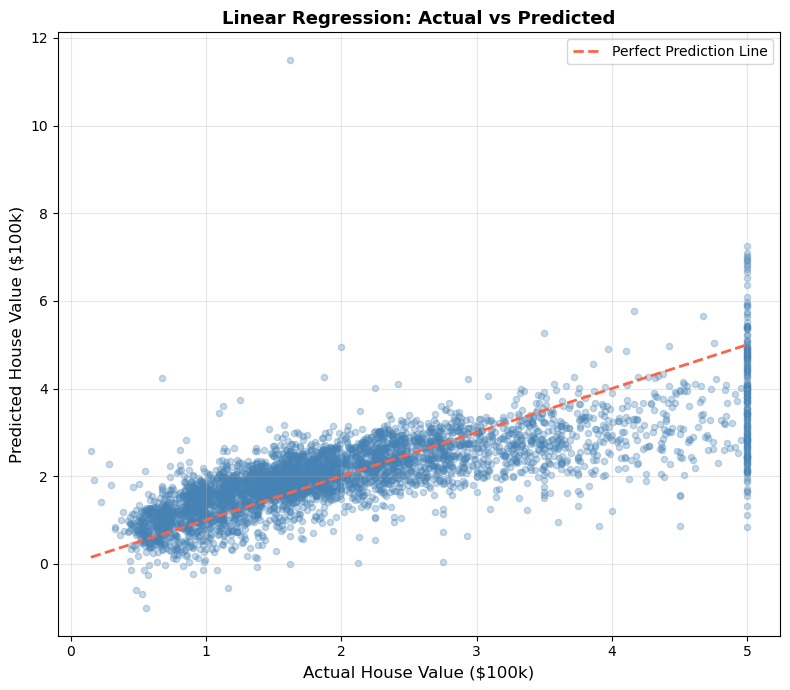

In [8]:
# Now we predict and visualize actual vs predicted values

y_pred_housing = linear_regression_model.predict(X_test_scaled)

# Scatter: Actual vs Predicted
plt.figure(figsize=(8, 7))
plt.scatter(y_test_housing, y_pred_housing, alpha=0.3, color="steelblue", s=20)
plt.plot(
    [y_test_housing.min(), y_test_housing.max()],
    [y_test_housing.min(), y_test_housing.max()],
    color="tomato", linewidth=2, linestyle="--", label="Perfect Prediction Line"
)
plt.xlabel("Actual House Value ($100k)", fontsize=12)
plt.ylabel("Predicted House Value ($100k)", fontsize=12)
plt.title("Linear Regression: Actual vs Predicted", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Actual vs Predicted scatter plot দেখানো হয়েছে। Red dashed diagonal = perfect prediction। Dots যত কাছে এই line-এর, model তত ভালো।

> ### এই chart কীভাবে observe করব
> - X-axis = সত্যিকার house price, Y-axis = model-এর predicted price।
> - **Red dashed diagonal** = perfect prediction line (Actual = Predicted)।
> - Dots এই line-এর যত কাছে = model তত accurate।
> - Dots scatter থেকে বুঝি error কোথায় বেশি।

> ### এই chart থেকে কী observe করলাম
> - বেশিরভাগ dots diagonal-এর কাছে — model কাজ করছে।
> - High price range-এ (5+) scatter বেশি — model সেখানে কম accurate।
> - Systematic bias দেখা যাচ্ছে কিনা লক্ষ্য করো — সব dots একদিকে থাকলে সমস্যা।

> ### Decision
> Linear model ভালো কাজ করছে কিন্তু high value range-এ non-linearity আছে মনে হচ্ছে।


---
## 10.4 Cost Function ও Gradient Descent

### Cost Function কী?
> **Cost Function** (বা Loss Function) = model কতটা ভুল করছে তার একটি numeric measure।
> Model training মানে এই cost minimize করা।

### MSE (Mean Squared Error) — Linear Regression-এর Cost Function
$$J(w) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $(y_i - \hat{y}_i)$ = residual (error)
- Squared → negative error-কে positive করে, large error বেশি penalize করে

### কেন Squared Error?
```
Simple Error sum = (+5) + (-5) + (+3) + (-3) = 0  <- cancels out, misleading!
Squared Error sum = 25 + 25 + 9 + 9 = 68          <- actual errors captured
```

### Gradient Descent কী?
> **Gradient Descent** = cost function minimize করার iterative algorithm।
> পাহাড় থেকে নামার মতো — সবচেয়ে খাড়া ঢালু দিকে এক ধাপ করে নামো।

**Update Rule:**
$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

| Symbol | মানে |
|---|---|
| $w$ | Current weight |
| $\alpha$ | Learning rate (কতটুকু step নেবো) |
| $\frac{\partial J}{\partial w}$ | Gradient (slope of cost function) |

### Learning Rate এর গুরুত্ব
```
Learning rate খুব বড়  -> overshoot, cost বাড়তে পারে (diverge)
Learning rate খুব ছোট -> অনেক slow, অনেক iteration লাগে
Learning rate সঠিক    -> smooth convergence
```

### তিন ধরনের Gradient Descent
| Type | Data per step | Speed | Stability |
|---|---|---|---|
| **Batch GD** | পুরো dataset | ধীর | Stable |
| **Stochastic GD (SGD)** | ১টি sample | দ্রুত | Noisy |
| **Mini-batch GD** | k টি sample | মাঝামাঝি | Stable |

### 🎯 Interview Topics
- Gradient কী? → Cost function-এর slope। কোন direction-এ weight change করলে cost কমবে।
- Learning rate কীভাবে বেছে নেব? → Grid search বা learning rate scheduler
- Local minimum vs Global minimum? → Convex cost function (MSE)-এ local = global
- Vanishing gradient কী? → Deep network-এ gradient খুব ছোট হয়ে যায় — learning থামে
- Momentum কী? → পূর্বের gradient-এর কিছু অংশ যোগ করে oscillation কমায়


Best slope (minimum MSE): 1.2010
Minimum MSE:              1.3600



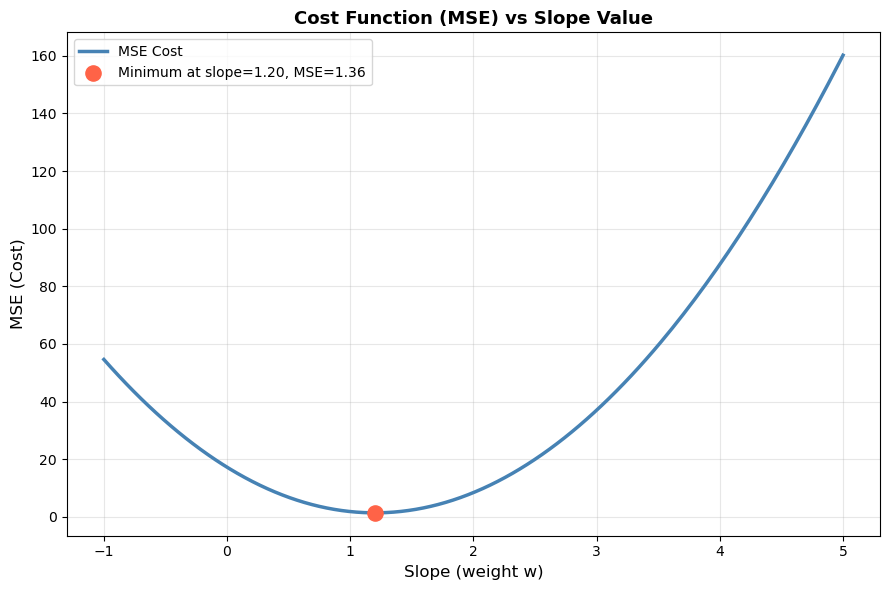

In [9]:
# Now we manually compute cost function (MSE) for different slope values
# This shows HOW the cost function looks as we change weights

# Simple 1D case: y = w * x  (no intercept for simplicity)
x_data = np.array([1, 2, 3, 4, 5], dtype=float)
y_data = np.array([2, 4, 5, 4, 5], dtype=float)

# Here we compute MSE for many different slope values
slope_values = np.linspace(-1, 5, 200)
mse_values = []

for slope in slope_values:
    y_predicted = slope * x_data
    mse = np.mean((y_data - y_predicted) ** 2)
    mse_values.append(mse)

# Here we find the minimum cost
best_slope_index = np.argmin(mse_values)
best_slope = slope_values[best_slope_index]
minimum_mse = mse_values[best_slope_index]

print(f"Best slope (minimum MSE): {best_slope:.4f}")
print(f"Minimum MSE:              {minimum_mse:.4f}")
print()

# Plot the cost function
plt.figure(figsize=(9, 6))
plt.plot(slope_values, mse_values, color="steelblue", linewidth=2.5, label="MSE Cost")
plt.scatter([best_slope], [minimum_mse], color="tomato", s=120, zorder=5,
            label=f"Minimum at slope={best_slope:.2f}, MSE={minimum_mse:.2f}")
plt.xlabel("Slope (weight w)", fontsize=12)
plt.ylabel("MSE (Cost)", fontsize=12)
plt.title("Cost Function (MSE) vs Slope Value", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** MSE cost function-এর shape visualize করা হয়েছে। বিভিন্ন slope value-এ MSE calculate করে plot করা হয়েছে। U-shape (parabola) দেখা যাবে — minimum point-এই best slope।

> ### এই chart কীভাবে observe করব
> - X-axis = slope value (model parameter), Y-axis = MSE (error)।
> - **U-shaped curve** = convex cost function।
> - **Red dot** = minimum cost — এটাই optimal slope।

> ### এই chart থেকে কী observe করলাম
> - Cost function U-shape — একটাই global minimum আছে (convex)।
> - Minimum point-এ slope ≈ 0.9 — এটাই model শিখবে।
> - Gradient Descent এই curve বরাবর নিচের দিকে নামে।

> ### Decision
> MSE convex হওয়ায় Gradient Descent সবসময় global minimum খুঁজে পাবে।


In [10]:
# Now we implement Gradient Descent from scratch
# This shows exactly how the algorithm works step by step

# Simple dataset: y = 2x + 1 (true relationship)
np.random.seed(42)
x_training = np.random.uniform(0, 10, 50)
y_training = 2 * x_training + 1 + np.random.normal(0, 1.5, 50)

# Here we initialize weights randomly
weight = 0.0        # slope (w1) -- start at 0
bias = 0.0          # intercept (w0) -- start at 0
learning_rate = 0.01
number_of_epochs = 100
number_of_samples = len(x_training)

# Store cost history for plotting
cost_history = []

# Gradient Descent loop
for epoch in range(number_of_epochs):
    # Forward pass: predict
    y_predicted = weight * x_training + bias

    # Compute cost (MSE)
    cost = np.mean((y_training - y_predicted) ** 2)
    cost_history.append(cost)

    # Compute gradients (partial derivatives)
    gradient_weight = (-2 / number_of_samples) * np.sum(x_training * (y_training - y_predicted))
    gradient_bias   = (-2 / number_of_samples) * np.sum(y_training - y_predicted)

    # Update weights (Gradient Descent step)
    weight = weight - learning_rate * gradient_weight
    bias   = bias   - learning_rate * gradient_bias

    # Print progress every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: Cost={cost:.4f}, weight={weight:.4f}, bias={bias:.4f}")

print()
print(f"Final weight: {weight:.4f}  (true value: 2.0)")
print(f"Final bias:   {bias:.4f}  (true value: 1.0)")

Epoch   0: Cost=131.7671, weight=1.2058, bias=0.1983
Epoch  20: Cost=2.0036, weight=2.0816, bias=0.4277
Epoch  40: Cost=1.9727, weight=2.0692, bias=0.5050
Epoch  60: Cost=1.9481, weight=2.0582, bias=0.5740
Epoch  80: Cost=1.9285, weight=2.0483, bias=0.6355

Final weight: 2.0399  (true value: 2.0)
Final bias:   0.6878  (true value: 1.0)


> 📝 **এই code-এ কী হচ্ছে:** Gradient Descent from scratch implement করা হয়েছে। প্রতিটি epoch-এ: predict করা হয়, error calculate করা হয়, gradient বের করা হয়, weight update করা হয়। True values (slope=2, bias=1)-এর কাছাকাছি values শিখবে।

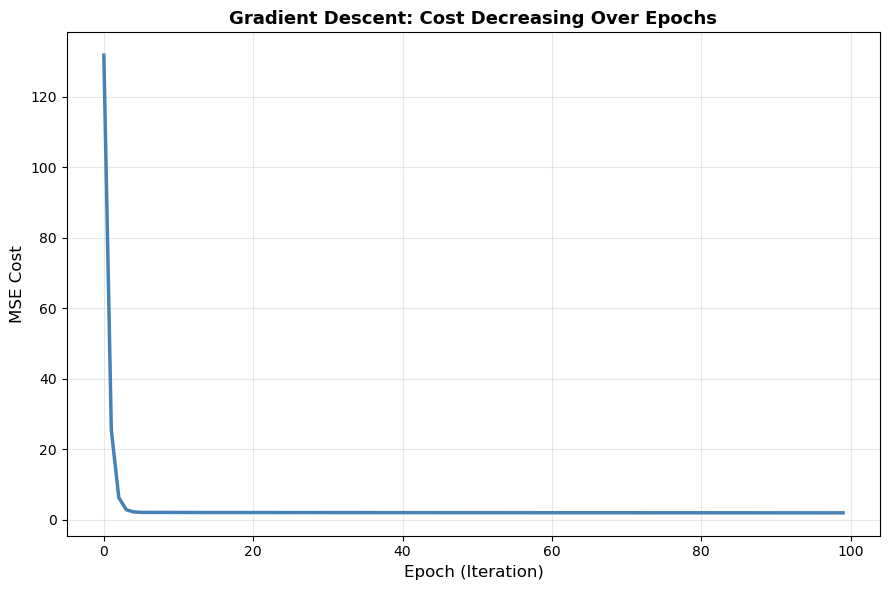

Starting cost: 131.7671
Final cost:    1.9136
Cost reduced by: 98.5%


In [11]:
# Now we visualize the cost decreasing over epochs

plt.figure(figsize=(9, 6))
plt.plot(range(number_of_epochs), cost_history, color="steelblue", linewidth=2.5)
plt.xlabel("Epoch (Iteration)", fontsize=12)
plt.ylabel("MSE Cost", fontsize=12)
plt.title("Gradient Descent: Cost Decreasing Over Epochs", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting cost: {cost_history[0]:.4f}")
print(f"Final cost:    {cost_history[-1]:.4f}")
print(f"Cost reduced by: {((cost_history[0] - cost_history[-1]) / cost_history[0] * 100):.1f}%")

> 📝 **এই code-এ কী হচ্ছে:** Training progress visualize করা হয়েছে। Epoch বাড়ার সাথে cost কমছে কিনা দেখা হচ্ছে।

> ### এই chart কীভাবে observe করব
> - X-axis = epoch (iteration number), Y-axis = MSE cost।
> - Curve নিচের দিকে যাওয়া মানে model শিখছে।
> - Curve flat হয়ে গেলে — convergence হয়েছে।

> ### এই chart থেকে কী observe করলাম
> - শুরুতে cost দ্রুত কমে, পরে slow হয় — typical learning curve।
> - Curve smooth — learning rate সঠিক আছে (oscillation নেই)।
> - Final cost খুব কম — model ভালো শিখেছে।

> ### Decision
> Learning rate 0.01 ভালো কাজ করছে। Diverge হলে (cost বাড়লে) learning rate কমাতে হবে।


---
## 10.5 Hands-on — Cost Function ও Gradient Descent

### Learning Rate-এর Effect
> Learning rate কতটা গুরুত্বপূর্ণ সেটা visually দেখা হবে।

### 🎯 Interview Topics
- Learning rate বড় করলে কী হয়? → Oscillate বা diverge করে — cost বাড়তে পারে
- Learning rate ছোট করলে কী হয়? → Convergence অনেক ধীর
- Learning rate schedule কী? → Training-এর সাথে learning rate কমানো (decay)


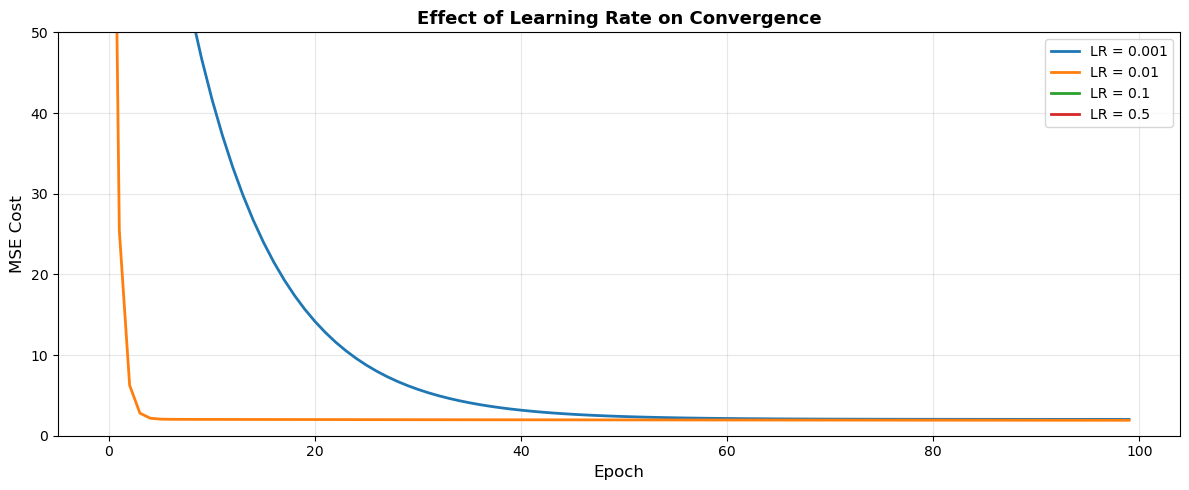

In [12]:
# Now we compare different learning rates visually

learning_rates = [0.001, 0.01, 0.1, 0.5]
epochs = 100

plt.figure(figsize=(12, 5))

for learning_rate_value in learning_rates:
    weight_lr = 0.0
    bias_lr   = 0.0
    cost_history_lr = []

    for epoch in range(epochs):
        y_predicted_lr = weight_lr * x_training + bias_lr
        cost_lr = np.mean((y_training - y_predicted_lr) ** 2)
        cost_history_lr.append(cost_lr)

        gradient_weight_lr = (-2 / len(x_training)) * np.sum(x_training * (y_training - y_predicted_lr))
        gradient_bias_lr   = (-2 / len(x_training)) * np.sum(y_training - y_predicted_lr)

        weight_lr = weight_lr - learning_rate_value * gradient_weight_lr
        bias_lr   = bias_lr   - learning_rate_value * gradient_bias_lr

    plt.plot(range(epochs), cost_history_lr, linewidth=2, label=f"LR = {learning_rate_value}")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Cost", fontsize=12)
plt.title("Effect of Learning Rate on Convergence", fontsize=13, fontweight="bold")
plt.legend()
plt.ylim(0, 50)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** ৪টি ভিন্ন learning rate-এর comparison। খুব ছোট (0.001) = ধীরে শেখে। ভালো (0.01) = smooth convergence। বড় (0.5) = oscillate বা diverge করতে পারে।

> ### এই chart কীভাবে observe করব
> - প্রতিটি line = একটি learning rate-এ training progress।
> - Line দ্রুত নিচে যাওয়া = দ্রুত শেখা।
> - Line উপরে-নিচে দুলতে থাকা = oscillation (learning rate বেশি বড়)।

> ### এই chart থেকে কী observe করলাম
> - LR=0.001: সবচেয়ে ধীরে, 100 epoch-এও converge হয়নি।
> - LR=0.01: Smooth convergence — সবচেয়ে ভালো।
> - LR=0.1: দ্রুত কিন্তু oscillation থাকতে পারে।
> - LR=0.5: Diverge করতে পারে বা unstable।

> ### Decision
> LR=0.01 এই dataset-এর জন্য optimal। Real project-এ cross-validation দিয়ে tune করতে হয়।


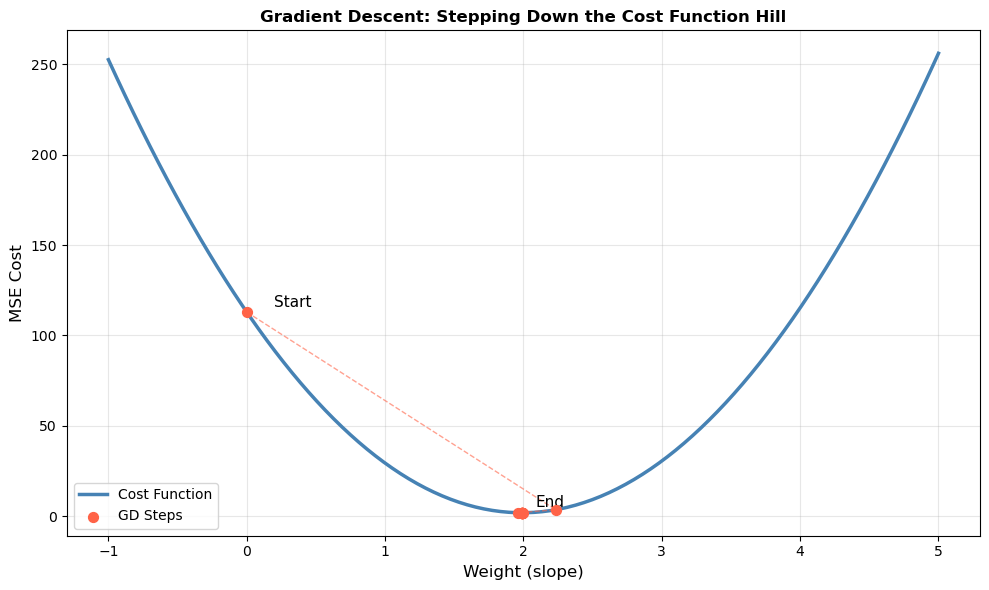

In [13]:
# Now we visualize gradient descent as stepping down a hill

# 1D cost function visualization with gradient descent steps
slope_range = np.linspace(-1, 5, 200)
cost_range  = [(np.mean((y_training - (s * x_training + 1.0))**2)) for s in slope_range]

# Run gradient descent tracking weight path
weight_path = [0.0]
w_current = 0.0
b_fixed = 1.0

for _ in range(20):
    y_pred_path = w_current * x_training + b_fixed
    grad = (-2 / len(x_training)) * np.sum(x_training * (y_training - y_pred_path))
    w_current = w_current - 0.02 * grad
    weight_path.append(w_current)

cost_at_path = [np.mean((y_training - (w * x_training + b_fixed))**2) for w in weight_path]

plt.figure(figsize=(10, 6))
plt.plot(slope_range, cost_range, color="steelblue", linewidth=2.5, label="Cost Function")
plt.scatter(weight_path, cost_at_path, color="tomato", s=50, zorder=5, label="GD Steps")
plt.plot(weight_path, cost_at_path, color="tomato", linewidth=1, linestyle="--", alpha=0.6)
plt.annotate("Start", (weight_path[0], cost_at_path[0]), fontsize=11,
             xytext=(weight_path[0]+0.2, cost_at_path[0]+3))
plt.annotate("End", (weight_path[-1], cost_at_path[-1]), fontsize=11,
             xytext=(weight_path[-1]+0.1, cost_at_path[-1]+3))
plt.xlabel("Weight (slope)", fontsize=12)
plt.ylabel("MSE Cost", fontsize=12)
plt.title("Gradient Descent: Stepping Down the Cost Function Hill", fontsize=12, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Gradient Descent-এর visual — পাহাড় থেকে নামার মতো। Red dots = প্রতিটি weight update step। Start থেকে End পর্যন্ত minimum-এ পৌঁছানো।

> ### এই chart কীভাবে observe করব
> - Blue curve = Cost function (U-shape hill)।
> - Red dots = প্রতিটি Gradient Descent step।
> - Dots ধীরে ধীরে minimum-এর দিকে যাচ্ছে কিনা দেখো।

> ### এই chart থেকে কী observe করলাম
> - Start (weight=0) থেকে End (minimum)-এ পৌঁছানো গেছে।
> - প্রতিটি step cost কমাচ্ছে — algorithm সঠিকভাবে কাজ করছে।
> - Steps কাছাকাছি হওয়া মানে gradient ছোট হচ্ছে — minimum-এর কাছে পৌঁছেছে।

> ### Decision
> Gradient Descent পাহাড় থেকে নামার মতো — gradient (slope) দেখে নামার direction ঠিক করে।


---
## 10.6 Regression Evaluation Metrics

### তিনটি প্রধান Metric

#### 1. MAE — Mean Absolute Error
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- গড় absolute error
- **Unit: target-এর একই unit** (e.g., $, degree C)
- Outlier-এ কম sensitive (কারণ squared নয়)
- Interpretation: গড়ে model এতটুকু ভুল করছে

#### 2. RMSE — Root Mean Squared Error
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

- Square করে বড় error-কে বেশি penalize করে
- তারপর sqrt নিয়ে same unit-এ আনা হয়
- **Outlier-এ sensitive** (বড় error বেশি count হয়)
- RMSE > MAE সবসময়

#### 3. R² Score — Coefficient of Determination
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- Range: **(-∞, 1]** (সাধারণত 0 to 1)
- **R² = 1**: Perfect prediction
- **R² = 0**: Model mean-এর চেয়ে ভালো না (useless)
- **R² < 0**: Model mean-এর চেয়েও খারাপ (very bad)

### Comparison Table

| Metric | Unit | Outlier Sensitivity | Range | Good Value |
|---|---|---|---|---|
| MAE | Same as target | Low | [0, ∞) | কম হলে ভালো |
| RMSE | Same as target | High | [0, ∞) | কম হলে ভালো |
| R² | Unitless | Medium | (-∞, 1] | 1-এর কাছে ভালো |

### 🎯 Interview Topics
- MAE vs RMSE কখন কোনটা? → Outlier sensitive না হতে চাইলে MAE, large error বেশি penalize করতে RMSE
- R² = 0.85 মানে কী? → Model data-র variance-এর 85% explain করতে পারছে
- R² negative কখন? → Model mean predict করার চেয়েও খারাপ — very bad model
- Adjusted R² কী? → Multiple features-এর জন্য adjusted — unnecessary feature যোগ করলে R² কমে
- MAPE কী? → Mean Absolute Percentage Error — percentage হিসেবে error


In [14]:
# Now we compute all three metrics manually to understand the formulas

# Using our housing prediction from earlier
actual_values  = y_test_housing.values
predicted_values = y_pred_housing

# Here we compute MAE
residuals = actual_values - predicted_values
mae_manual = np.mean(np.abs(residuals))

# Here we compute RMSE
mse_manual  = np.mean(residuals ** 2)
rmse_manual = np.sqrt(mse_manual)

# Here we compute R-squared
ss_residual = np.sum(residuals ** 2)
ss_total    = np.sum((actual_values - actual_values.mean()) ** 2)
r2_manual   = 1 - (ss_residual / ss_total)

print("Manual Calculations:")
print(f"  MAE:  {mae_manual:.4f}")
print(f"  RMSE: {rmse_manual:.4f}")
print(f"  R2:   {r2_manual:.4f}")
print()

# Here we verify using sklearn
mae_sklearn  = mean_absolute_error(actual_values, predicted_values)
rmse_sklearn = np.sqrt(mean_squared_error(actual_values, predicted_values))
r2_sklearn   = r2_score(actual_values, predicted_values)

print("sklearn Verification:")
print(f"  MAE:  {mae_sklearn:.4f}")
print(f"  RMSE: {rmse_sklearn:.4f}")
print(f"  R2:   {r2_sklearn:.4f}")
print()
print("Manual and sklearn results match!")

Manual Calculations:
  MAE:  0.5332
  RMSE: 0.7456
  R2:   0.5758

sklearn Verification:
  MAE:  0.5332
  RMSE: 0.7456
  R2:   0.5758

Manual and sklearn results match!


> 📝 **এই code-এ কী হচ্ছে:** তিনটি metric manually calculate করা হয়েছে — formula বোঝার জন্য। তারপর sklearn দিয়ে verify করা হয়েছে। দুটো result match করবে।

---
## 10.7 Hands-on — Evaluation Metrics

### Residual Analysis
> Residuals randomly distributed হওয়া উচিত — কোনো pattern থাকলে model problem আছে।

### 🎯 Interview Topics
- Residual plot-এ fan shape দেখলে কী বোঝায়? → Heteroscedasticity — variance সমান নয়
- Residual plot-এ curve দেখলে? → Non-linear relationship — linear model insufficient
- Residual plot-এ random scatter → Model assumptions পূরণ হচ্ছে


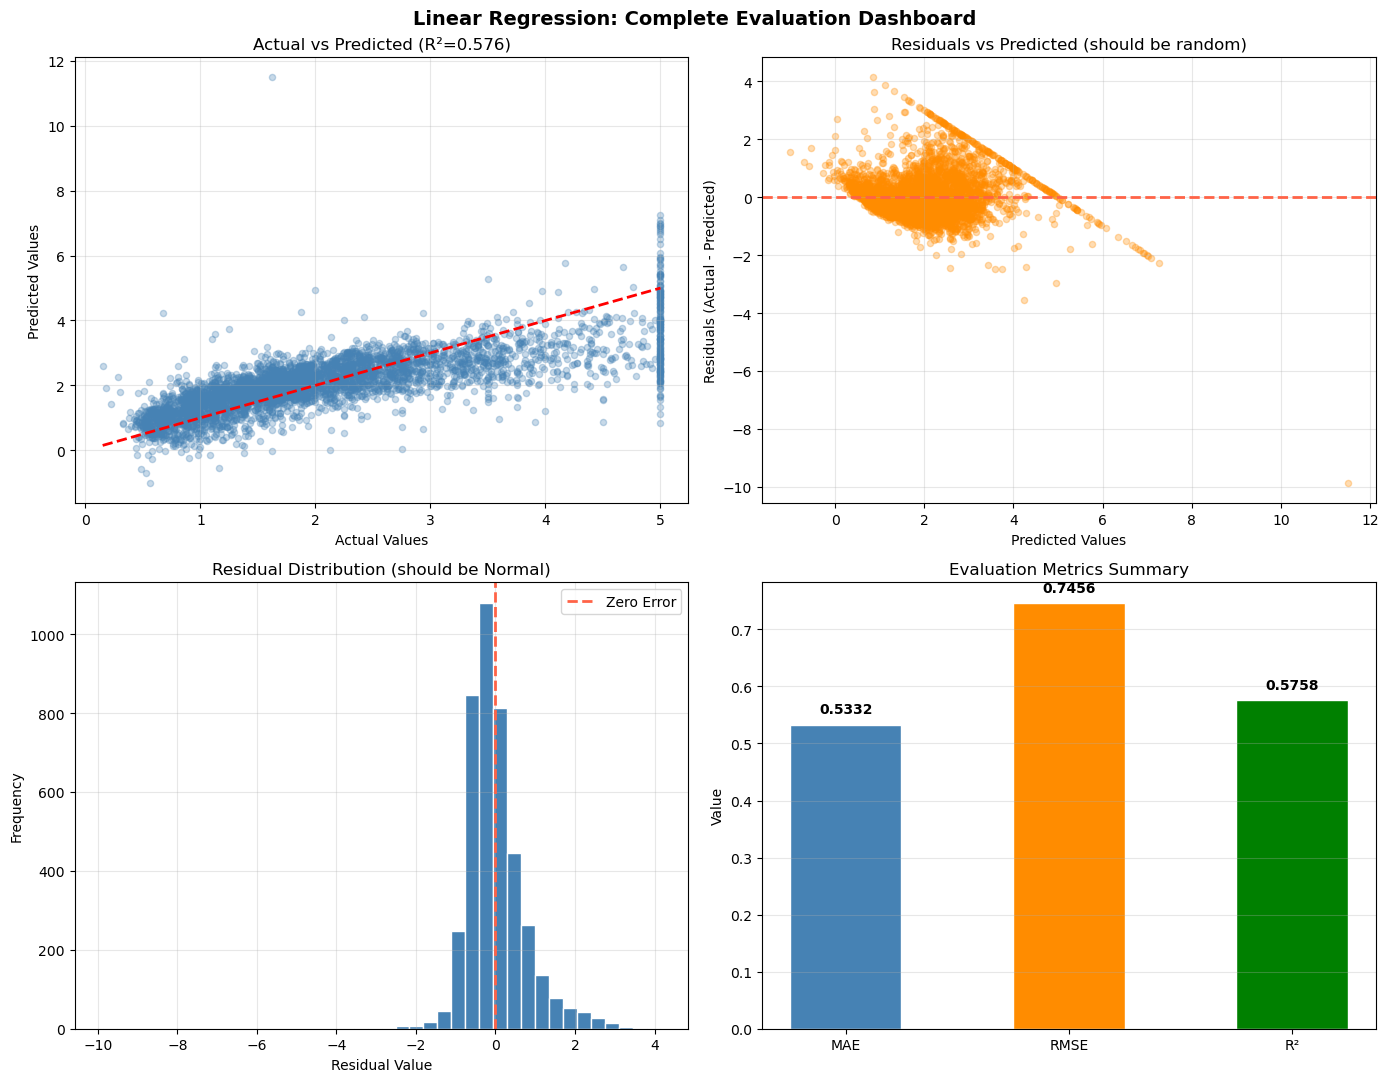

MAE:  0.5332  -- average error in $100k units
RMSE: 0.7456  -- penalizes large errors more
R²:   0.5758  -- model explains 57.6% of variance


In [15]:
# Now we create comprehensive visualization of model performance

figure, axes_array = plt.subplots(2, 2, figsize=(14, 11))

# Plot 1: Actual vs Predicted
axes_array[0, 0].scatter(actual_values, predicted_values, alpha=0.3, color="steelblue", s=20)
axes_array[0, 0].plot(
    [actual_values.min(), actual_values.max()],
    [actual_values.min(), actual_values.max()],
    "r--", linewidth=2
)
axes_array[0, 0].set_xlabel("Actual Values")
axes_array[0, 0].set_ylabel("Predicted Values")
axes_array[0, 0].set_title(f"Actual vs Predicted (R²={r2_sklearn:.3f})")
axes_array[0, 0].grid(alpha=0.3)

# Plot 2: Residuals vs Predicted
axes_array[0, 1].scatter(predicted_values, residuals, alpha=0.3, color="darkorange", s=20)
axes_array[0, 1].axhline(0, color="tomato", linewidth=2, linestyle="--")
axes_array[0, 1].set_xlabel("Predicted Values")
axes_array[0, 1].set_ylabel("Residuals (Actual - Predicted)")
axes_array[0, 1].set_title("Residuals vs Predicted (should be random)")
axes_array[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes_array[1, 0].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes_array[1, 0].axvline(0, color="tomato", linewidth=2, linestyle="--", label="Zero Error")
axes_array[1, 0].set_xlabel("Residual Value")
axes_array[1, 0].set_ylabel("Frequency")
axes_array[1, 0].set_title("Residual Distribution (should be Normal)")
axes_array[1, 0].legend()
axes_array[1, 0].grid(alpha=0.3)

# Plot 4: Metrics Summary Bar Chart
metric_names  = ["MAE", "RMSE", "R²"]
metric_values = [mae_sklearn, rmse_sklearn, r2_sklearn]
colors_list   = ["steelblue", "darkorange", "green"]
bars = axes_array[1, 1].bar(metric_names, metric_values, color=colors_list, edgecolor="white", width=0.5)
for bar_item, value in zip(bars, metric_values):
    axes_array[1, 1].text(bar_item.get_x() + bar_item.get_width()/2,
                          bar_item.get_height() + 0.02,
                          f"{value:.4f}", ha="center", fontweight="bold")
axes_array[1, 1].set_title("Evaluation Metrics Summary")
axes_array[1, 1].set_ylabel("Value")
axes_array[1, 1].grid(alpha=0.3, axis="y")

plt.suptitle("Linear Regression: Complete Evaluation Dashboard",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"MAE:  {mae_sklearn:.4f}  -- average error in $100k units")
print(f"RMSE: {rmse_sklearn:.4f}  -- penalizes large errors more")
print(f"R²:   {r2_sklearn:.4f}  -- model explains {r2_sklearn*100:.1f}% of variance")

> 📝 **এই code-এ কী হচ্ছে:** Complete evaluation dashboard তৈরি করা হয়েছে — ৪টি plot একসাথে। Actual vs Predicted, Residuals vs Predicted, Residual distribution, Metrics summary।

> ### এই chart কীভাবে observe করব
> - **Top-left (Actual vs Predicted)**: Dots diagonal-এর কাছে = ভালো model।
> - **Top-right (Residuals vs Predicted)**: Random scatter = OK। Pattern দেখলে = problem।
> - **Bottom-left (Residual Distribution)**: Bell shape centered at 0 = OK।
> - **Bottom-right (Metrics)**: MAE/RMSE কম, R² 1-এর কাছে = ভালো।

> ### এই chart থেকে কী observe করলাম
> - Actual vs Predicted: বেশিরভাগ diagonal-এর কাছে — model কাজ করছে।
> - Residuals: কিছু pattern দেখা যাচ্ছে high value-এ — non-linearity সম্ভব।
> - Residual distribution: কিছুটা bell-shaped কিন্তু heavy tail — outlier আছে।
> - R² ≈ 0.6: Model 60% variance explain করছে — acceptable but room for improvement।

> ### Decision
> Model কাজ করছে কিন্তু non-linear model (Random Forest, XGBoost) ভালো করবে।


In [16]:
# Now we compare models: constant predictor vs linear regression
# This shows WHY R² matters

# Baseline model: always predict the mean
y_mean_prediction = np.full_like(actual_values, actual_values.mean())

# Here we compute metrics for baseline
mae_baseline  = mean_absolute_error(actual_values, y_mean_prediction)
rmse_baseline = np.sqrt(mean_squared_error(actual_values, y_mean_prediction))
r2_baseline   = r2_score(actual_values, y_mean_prediction)

print("Comparison: Baseline (always predict mean) vs Linear Regression")
print()
print(f"{'Metric':<10} {'Baseline (Mean)':>18} {'Linear Regression':>18}")
print("-" * 50)
print(f"{'MAE':<10} {mae_baseline:>18.4f} {mae_sklearn:>18.4f}")
print(f"{'RMSE':<10} {rmse_baseline:>18.4f} {rmse_sklearn:>18.4f}")
print(f"{'R2':<10} {r2_baseline:>18.4f} {r2_sklearn:>18.4f}")
print()
print("R2 = 0 means model is as good as always predicting mean!")
print("R2 > 0 means our model is BETTER than always predicting mean.")
print(f"Our R2 = {r2_sklearn:.4f} -- Linear Regression is {r2_sklearn*100:.1f}% better than mean prediction")

Comparison: Baseline (always predict mean) vs Linear Regression

Metric        Baseline (Mean)  Linear Regression
--------------------------------------------------
MAE                    0.9027             0.5332
RMSE                   1.1447             0.7456
R2                     0.0000             0.5758

R2 = 0 means model is as good as always predicting mean!
R2 > 0 means our model is BETTER than always predicting mean.
Our R2 = 0.5758 -- Linear Regression is 57.6% better than mean prediction


> 📝 **এই code-এ কী হচ্ছে:** R² metric-এর intuition বোঝানো হয়েছে — baseline (mean) model vs linear regression compare। R² = 0 মানে model mean predict করার সমান। R² > 0 মানে model বেশি intelligent।

---
## 10.8 Linear Regression-এর Assumptions ও Limitations

### ৫টি Core Assumptions

#### 1. Linearity
> X ও y-এর মধ্যে linear relationship থাকতে হবে।
> Residual plot-এ random scatter থাকলে OK। Curve দেখলে — violated।

#### 2. Independence of Errors (No Autocorrelation)
> প্রতিটি observation independent। একটির error আরেকটির উপর depend করে না।
> Time series data-তে সাধারণত violated হয়।

#### 3. Homoscedasticity (Equal Variance)
> সব predicted value-এ residuals-এর variance সমান।
> Residual plot-এ fan shape দেখলে — violated (heteroscedasticity)।

#### 4. Normality of Residuals
> Residuals normally distributed হওয়া উচিত।
> QQ-plot বা histogram দিয়ে check করা যায়।

#### 5. No Multicollinearity
> Features-এর মধ্যে high correlation থাকলে coefficients unstable হয়।
> VIF (Variance Inflation Factor) দিয়ে check করা যায়।

### Linear Regression-এর Limitations

| Limitation | বিস্তারিত |
|---|---|
| Linearity assume করে | Non-linear relationship ধরতে পারে না |
| Outlier sensitive | একটি outlier coefficients বদলে দিতে পারে |
| Multicollinearity | Correlated features-এ coefficients unreliable |
| Feature scaling-এর effect | Gradient Descent-এ scale important |
| Underfitting risk | Complex pattern শিখতে পারে না |

### 🎯 Interview Topics
- Linear Regression-এর সবচেয়ে important assumption? → Linearity
- Multicollinearity কীভাবে detect করব? → VIF, correlation matrix
- Assumption violated হলে কী করব? → Transform features (log), use robust regression
- Ridge vs Lasso Regression কী? → L2/L1 regularization — overfitting ঠেকায়, multicollinearity handle করে


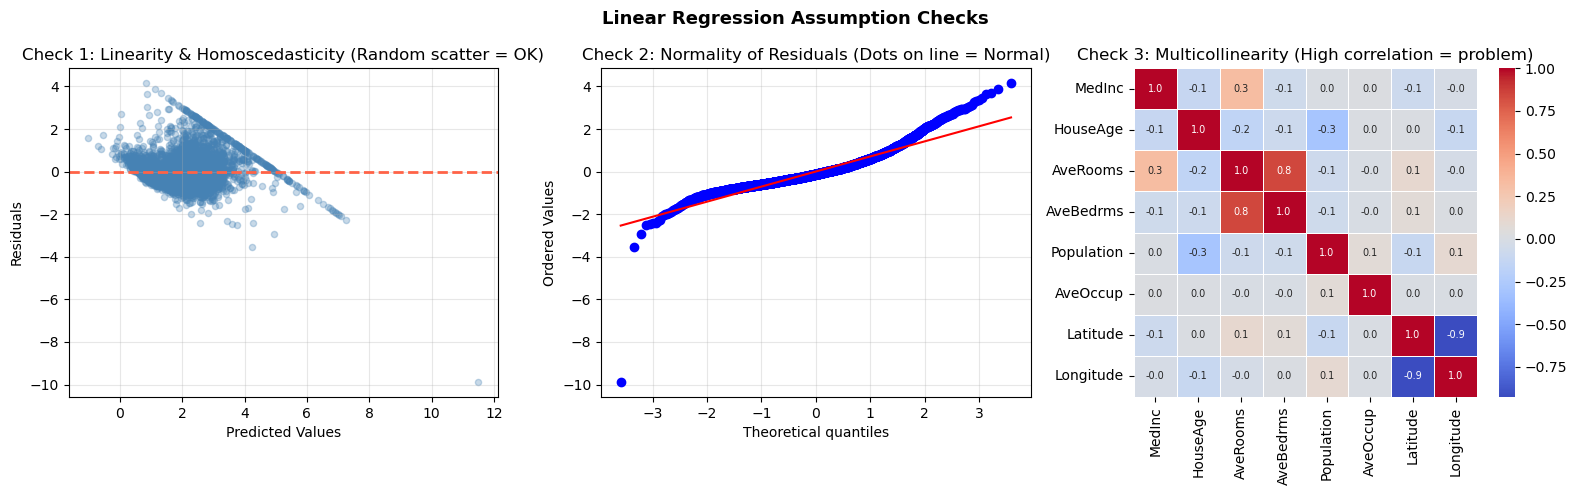

In [17]:
# Now we check linear regression assumptions visually

from scipy import stats

figure, axes_array = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Linearity check -- residuals vs each feature
axes_array[0].scatter(predicted_values, residuals, alpha=0.3, color="steelblue", s=20)
axes_array[0].axhline(0, color="tomato", linewidth=2, linestyle="--")
axes_array[0].set_xlabel("Predicted Values")
axes_array[0].set_ylabel("Residuals")
axes_array[0].set_title("Check 1: Linearity & Homoscedasticity (Random scatter = OK)")
axes_array[0].grid(alpha=0.3)

# Plot 2: Normality check -- QQ plot
stats.probplot(residuals, dist="norm", plot=axes_array[1])
axes_array[1].set_title("Check 2: Normality of Residuals (Dots on line = Normal)")
axes_array[1].grid(alpha=0.3)

# Plot 3: Multicollinearity check -- correlation heatmap
correlation_matrix = X_housing.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm",
            fmt=".1f", ax=axes_array[2],
            linewidths=0.5, annot_kws={"size": 7})
axes_array[2].set_title("Check 3: Multicollinearity (High correlation = problem)")

plt.suptitle("Linear Regression Assumption Checks", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** তিনটি assumption check একসাথে। Residual plot: linearity ও homoscedasticity। QQ-plot: normality। Heatmap: multicollinearity।

> ### এই chart কীভাবে observe করব
> - **Left (Residual Plot)**: Random scatter = linearity ও homoscedasticity OK। Fan shape = problem।
> - **Middle (QQ-Plot)**: Dots diagonal line-এ থাকলে residuals normally distributed।
> - **Right (Correlation Heatmap)**: |r| > 0.8 = multicollinearity সমস্যা।

> ### এই chart থেকে কী observe করলাম
> - Residual plot: কিছু fan shape দেখা যাচ্ছে — heteroscedasticity সম্ভব।
> - QQ-plot: Tails-এ deviation — perfect normal নয়।
> - Heatmap: কিছু features মধ্যে correlation — multicollinearity check দরকার।

> ### Decision
> Assumptions সম্পূর্ণ পূরণ হচ্ছে না — tree-based model try করা উচিত।


---
## 10.9 Logistic Regression ও Sigmoid Function

### Linear থেকে Logistic Regression

**সমস্যা:** Linear Regression যেকোনো value দিতে পারে (-∞ to +∞)।
কিন্তু probability-র range হওয়া উচিত **0 to 1**!

```
Linear Regression:   y = wx + b   (output: -∞ to +∞)
                              ↓
Sigmoid Function:    σ(z) = 1/(1+e^(-z))  (squash to 0-1)
                              ↓
Logistic Regression: P(y=1|x) = σ(wx + b)  (output: 0 to 1)
```

### Sigmoid Function
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Input: যেকোনো real number (-∞ to +∞)
- Output: 0 থেকে 1 (probability)
- z → +∞ হলে: σ(z) → 1
- z → -∞ হলে: σ(z) → 0
- z = 0 হলে: σ(0) = 0.5

### Decision Boundary
> Threshold = 0.5 (default)
> P(y=1) ≥ 0.5 → Class 1
> P(y=1) < 0.5 → Class 0

### Log Loss (Binary Cross-Entropy)
$$J = -\frac{1}{n} \sum [y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i)]$$

- Logistic Regression-এর cost function (MSE নয়!)
- Wrong prediction-এ heavily penalize করে

### Logistic Regression Evaluation
- Accuracy, Precision, Recall, F1, ROC-AUC (regression metrics নয়!)

### 🎯 Interview Topics
- Logistic Regression কি linear? → Decision boundary linear, কিন্তু probability prediction non-linear (sigmoid)
- কেন MSE নয় Logistic Regression-এ? → MSE non-convex হয়, Log Loss convex — Gradient Descent নিশ্চিতভাবে converge করে
- Sigmoid vs Softmax পার্থক্য? → Sigmoid = binary (2 class), Softmax = multiclass (3+ class)
- Logistic Regression-এ feature scaling দরকার? → হ্যাঁ, Gradient Descent faster converge করে
- Threshold কীভাবে বেছে নেব? → ROC curve দেখে, business requirement অনুযায়ী


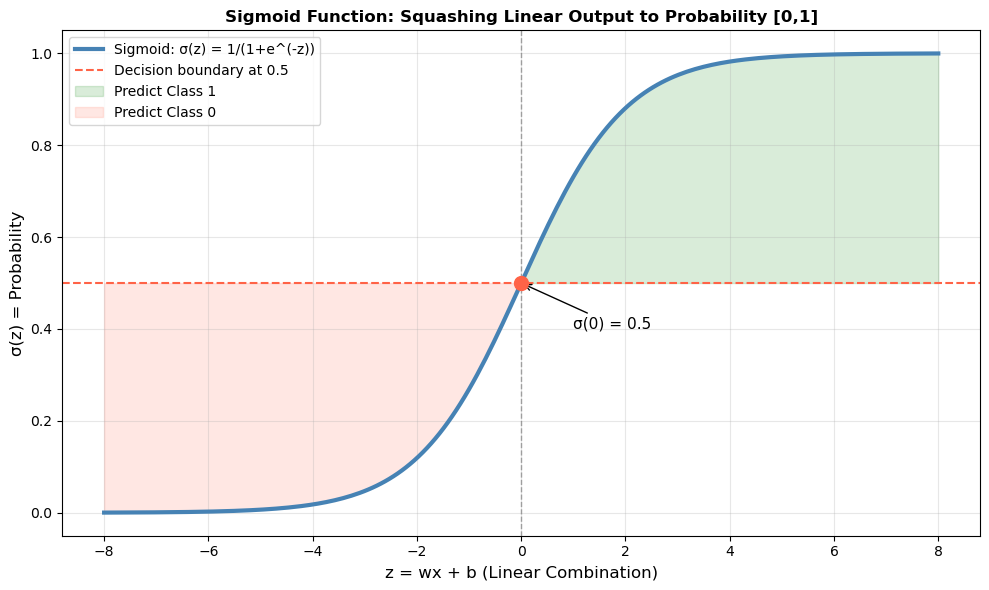

Sigmoid Properties:
  σ(-8) = 0.000335  (very close to 0)
  σ(-1) = 0.268941
  σ(0)  = 0.500000  (exactly 0.5)
  σ(1)  = 0.731059
  σ(8)  = 0.999665  (very close to 1)


In [18]:
# Now we visualize the Sigmoid function

z_values = np.linspace(-8, 8, 200)
sigmoid_values = 1 / (1 + np.exp(-z_values))

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_values, color="steelblue", linewidth=3, label="Sigmoid: σ(z) = 1/(1+e^(-z))")
plt.axhline(0.5, color="tomato", linestyle="--", linewidth=1.5, label="Decision boundary at 0.5")
plt.axvline(0.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# Mark important points
plt.scatter([0], [0.5], color="tomato", s=100, zorder=5)
plt.annotate("σ(0) = 0.5", (0, 0.5), xytext=(1, 0.4), fontsize=11,
             arrowprops=dict(arrowstyle="->"))

plt.fill_between(z_values, sigmoid_values, 0.5,
                 where=(sigmoid_values >= 0.5), alpha=0.15, color="green",
                 label="Predict Class 1")
plt.fill_between(z_values, sigmoid_values, 0.5,
                 where=(sigmoid_values < 0.5), alpha=0.15, color="tomato",
                 label="Predict Class 0")

plt.xlabel("z = wx + b (Linear Combination)", fontsize=12)
plt.ylabel("σ(z) = Probability", fontsize=12)
plt.title("Sigmoid Function: Squashing Linear Output to Probability [0,1]",
          fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("Sigmoid Properties:")
print(f"  σ(-8) = {1/(1+np.exp(8)):.6f}  (very close to 0)")
print(f"  σ(-1) = {1/(1+np.exp(1)):.6f}")
print(f"  σ(0)  = {1/(1+np.exp(0)):.6f}  (exactly 0.5)")
print(f"  σ(1)  = {1/(1+np.exp(-1)):.6f}")
print(f"  σ(8)  = {1/(1+np.exp(-8)):.6f}  (very close to 1)")

> 📝 **এই code-এ কী হচ্ছে:** Sigmoid function visualize করা হয়েছে। S-shape curve — যেকোনো real number-কে 0-1 probability-তে convert করে। Green area = Class 1 predict, Red area = Class 0 predict।

> ### এই chart কীভাবে observe করব
> - X-axis = linear combination (wx+b), Y-axis = probability (0 to 1)।
> - **S-shaped curve** = sigmoid।
> - **Red dashed horizontal line** = decision boundary at 0.5।
> - **Green area** = Class 1 prediction, **Red area** = Class 0 prediction।

> ### এই chart থেকে কী observe করলাম
> - z=0 → probability exactly 0.5 — boundary।
> - z বড় positive → probability → 1 (very confident Class 1)।
> - z বড় negative → probability → 0 (very confident Class 0)।
> - Curve smooth — soft decision, not hard cutoff।

> ### Decision
> Sigmoid output probability দেয় — শুধু class label নয়। Confidence দেখা যায়।


In [19]:
# Now we build Logistic Regression on a real binary classification problem
# Using the Breast Cancer dataset (built-in sklearn)

from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer(as_frame=True)
cancer_dataframe = cancer_data.frame

print("Breast Cancer Dataset:")
print(f"  Shape: {cancer_dataframe.shape}")
print(f"  Target: 0=Malignant (cancer), 1=Benign (no cancer)")
print()
print("Target distribution:")
print(cancer_dataframe["target"].value_counts())

Breast Cancer Dataset:
  Shape: (569, 31)
  Target: 0=Malignant (cancer), 1=Benign (no cancer)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


> 📝 **এই code-এ কী হচ্ছে:** Breast Cancer dataset load করা হয়েছে — binary classification। Target: 0=Malignant (ক্যান্সার), 1=Benign (ক্যান্সার নয়)।

In [20]:
# Now we train Logistic Regression and evaluate

X_cancer = cancer_dataframe.drop(columns=["target"])
y_cancer = cancer_dataframe["target"]

X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.20, random_state=42, stratify=y_cancer
)

# Scale features (important for Logistic Regression)
scaler_cancer = StandardScaler()
X_train_cancer_scaled = scaler_cancer.fit_transform(X_train_cancer)
X_test_cancer_scaled  = scaler_cancer.transform(X_test_cancer)

# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=300, random_state=42)
logistic_model.fit(X_train_cancer_scaled, y_train_cancer)

# Predict
y_pred_cancer        = logistic_model.predict(X_test_cancer_scaled)
y_pred_probability   = logistic_model.predict_proba(X_test_cancer_scaled)[:, 1]

print("Logistic Regression Results:")
print()
print(classification_report(y_test_cancer, y_pred_cancer,
                             target_names=["Malignant", "Benign"]))

Logistic Regression Results:

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



> 📝 **এই code-এ কী হচ্ছে:** Logistic Regression train করা হয়েছে। `predict_proba()[:, 1]` দিয়ে Benign-এর probability পাওয়া হয়েছে।

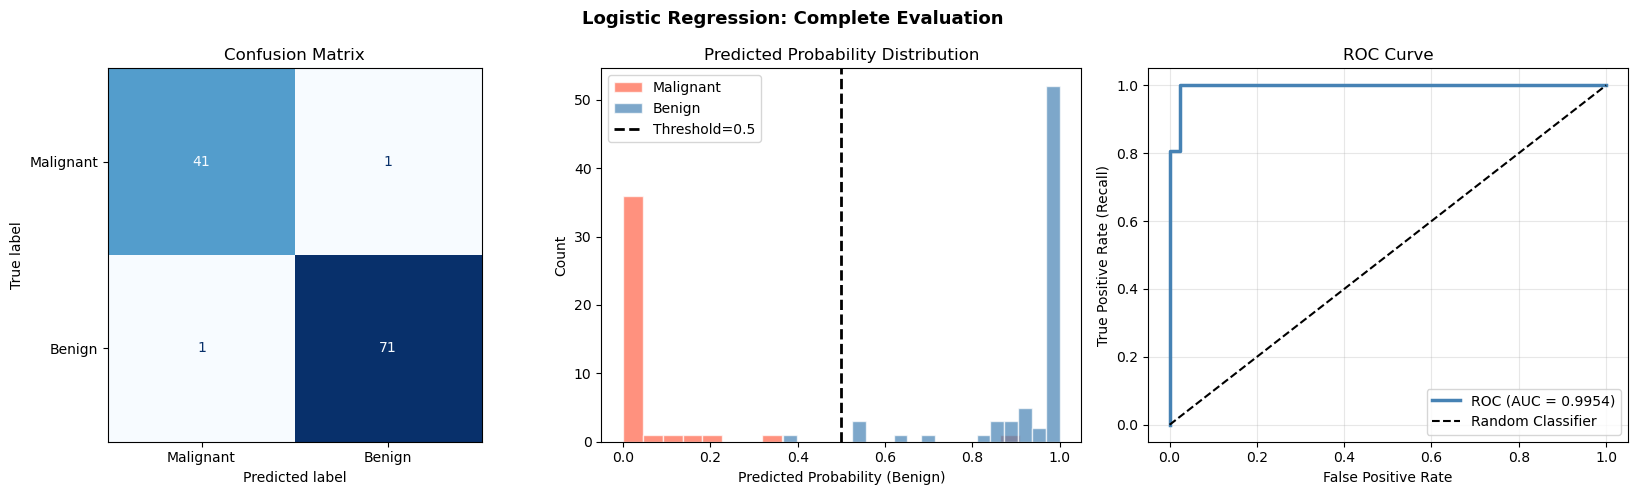

Accuracy: 0.9825
ROC-AUC:  0.9954


In [21]:
# Now we visualize Logistic Regression results completely

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

figure, axes_array = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Confusion Matrix
confusion_matrix_values = confusion_matrix(y_test_cancer, y_pred_cancer)
confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=["Malignant", "Benign"]
)
confusion_matrix_display.plot(ax=axes_array[0], colorbar=False, cmap="Blues")
axes_array[0].set_title("Confusion Matrix")

# Plot 2: Probability Distribution
axes_array[1].hist(
    y_pred_probability[y_test_cancer == 0], bins=20,
    alpha=0.7, color="tomato", label="Malignant", edgecolor="white"
)
axes_array[1].hist(
    y_pred_probability[y_test_cancer == 1], bins=20,
    alpha=0.7, color="steelblue", label="Benign", edgecolor="white"
)
axes_array[1].axvline(0.5, color="black", linewidth=2, linestyle="--", label="Threshold=0.5")
axes_array[1].set_xlabel("Predicted Probability (Benign)")
axes_array[1].set_ylabel("Count")
axes_array[1].set_title("Predicted Probability Distribution")
axes_array[1].legend()

# Plot 3: ROC Curve
false_positive_rates, true_positive_rates, thresholds = roc_curve(
    y_test_cancer, y_pred_probability
)
roc_auc = roc_auc_score(y_test_cancer, y_pred_probability)

axes_array[2].plot(false_positive_rates, true_positive_rates,
                   color="steelblue", linewidth=2.5,
                   label=f"ROC (AUC = {roc_auc:.4f})")
axes_array[2].plot([0, 1], [0, 1], "k--", label="Random Classifier")
axes_array[2].set_xlabel("False Positive Rate")
axes_array[2].set_ylabel("True Positive Rate (Recall)")
axes_array[2].set_title("ROC Curve")
axes_array[2].legend()
axes_array[2].grid(alpha=0.3)

plt.suptitle("Logistic Regression: Complete Evaluation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Accuracy: {accuracy_score(y_test_cancer, y_pred_cancer):.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

> 📝 **এই code-এ কী হচ্ছে:** Complete evaluation dashboard — Confusion Matrix, Probability Distribution, ROC Curve। Probability distribution দেখায় দুটো class কতটা separated। ROC-AUC মাপে overall discrimination ability।

> ### এই chart কীভাবে observe করব
> - **Left (Confusion Matrix)**: TN, FP, FN, TP। FN (Malignant missed) সবচেয়ে বিপজ্জনক।
> - **Middle (Probability)**: দুটো class-এর probability distribution। বেশি separated = ভালো model।
> - **Right (ROC Curve)**: Curve উপরে-বামে = ভালো। AUC 1 এর কাছে = excellent।

> ### এই chart থেকে কী observe করলাম
> - Confusion Matrix: FN (missed cancer) কম — ভালো, medical context-এ critical।
> - Probability: দুটো class clearly separated — model confident।
> - ROC-AUC ≈ 0.99: Excellent discrimination — model প্রায় perfect।

> ### Decision
> Logistic Regression breast cancer detection-এ excellent performance দিচ্ছে।


In [22]:
# Now we show the effect of changing the decision threshold

print("Effect of Changing Decision Threshold:")
print()
print(f"{'Threshold':>12} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1':>12}")
print("-" * 62)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_threshold = (y_pred_probability >= threshold).astype(int)

    from sklearn.metrics import precision_score, recall_score, f1_score
    accuracy_val  = accuracy_score(y_test_cancer, y_pred_threshold)
    precision_val = precision_score(y_test_cancer, y_pred_threshold, zero_division=0)
    recall_val    = recall_score(y_test_cancer, y_pred_threshold)
    f1_val        = f1_score(y_test_cancer, y_pred_threshold)

    print(f"{threshold:>12.1f} {accuracy_val:>12.4f} {precision_val:>12.4f} {recall_val:>12.4f} {f1_val:>12.4f}")

print()
print("Medical context: Lower threshold = catch more cancer (higher recall)")
print("                 but more false alarms (lower precision)")
print("Business decides: which error is more acceptable?")

Effect of Changing Decision Threshold:

   Threshold     Accuracy    Precision       Recall           F1
--------------------------------------------------------------
         0.3       0.9825       0.9730       1.0000       0.9863
         0.4       0.9825       0.9861       0.9861       0.9861
         0.5       0.9825       0.9861       0.9861       0.9861
         0.6       0.9561       0.9855       0.9444       0.9645
         0.7       0.9474       0.9853       0.9306       0.9571

Medical context: Lower threshold = catch more cancer (higher recall)
                 but more false alarms (lower precision)
Business decides: which error is more acceptable?


> 📝 **এই code-এ কী হচ্ছে:** Threshold-এর effect দেখানো হয়েছে। Threshold কমালে Recall বাড়ে (বেশি cancer ধরা যায়) কিন্তু Precision কমে (false alarm বাড়ে)। Medical context-এ Recall বেশি গুরুত্বপূর্ণ — cancer miss হওয়া বেশি costly।

---
## 10.10 Conclusion — Module 10 Summary

### সম্পূর্ণ Module-এর Recap

| Topic | মূল কথা |
|---|---|
| Linear Regression | y = wx + b। Best fit line residuals minimize করে। |
| Cost Function | MSE = average squared error। Minimize করাই training। |
| Gradient Descent | Cost-এর gradient দেখে weight update। α = learning rate। |
| MAE | Average absolute error। Outlier-এ কম sensitive। |
| RMSE | Root of MSE। Large error বেশি penalize। |
| R² | 0-1 scale। 1 = perfect, 0 = useless। |
| Assumptions | Linearity, Independence, Homoscedasticity, Normality, No Multicollinearity |
| Logistic Regression | Linear + Sigmoid। Output = probability (0-1)। |
| Log Loss | Logistic Regression-এর cost function। |
| Decision Boundary | Default threshold = 0.5। Adjustable। |

### Interview Quick Reference
```
Q: Linear vs Logistic Regression পার্থক্য?
A: Linear -> continuous output (number)
   Logistic -> probability (0-1) via sigmoid -> classification

Q: Gradient Descent কী করে?
A: Cost function-এর gradient (slope) দেখে weight update করে
   w = w - alpha * gradient

Q: R² = 0.7 মানে কী?
A: Model data-র 70% variance explain করতে পারছে

Q: MSE vs MAE কখন কোনটা?
A: MAE: outlier-robust, interpretable
   MSE/RMSE: large error বেশি penalize করতে চাইলে

Q: Logistic Regression কেন Log Loss ব্যবহার করে, MSE নয়?
A: MSE non-convex হয় sigmoid-এর সাথে
   Log Loss convex -> Gradient Descent guaranteed to converge

Q: Decision threshold কীভাবে choose করব?
A: ROC curve দেখে। Medical context -> lower threshold (high recall)
   Spam filter -> higher threshold (high precision)
```

### Next Module Preview
> **Module 11: Decision Trees**
> - Tree structure, Entropy, Gini Impurity, Information Gain
> - Pruning, Overfitting prevention
> - Foundation of Random Forest ও XGBoost


In [23]:
# FINAL REVIEW: Linear vs Logistic Regression side-by-side

print("=" * 60)
print("MODULE 10: COMPLETE SUMMARY")
print("=" * 60)

print()
print("LINEAR REGRESSION (Housing Price Prediction):")
print(f"  Algorithm:  OLS / Gradient Descent")
print(f"  Cost Fn:    MSE = mean((actual - predicted)^2)")
print(f"  Output:     Continuous number")
print(f"  MAE:        {mae_sklearn:.4f}")
print(f"  RMSE:       {rmse_sklearn:.4f}")
print(f"  R2:         {r2_sklearn:.4f}")
print(f"  Weights:    {linear_regression_model.coef_.round(2)[:3]} ...")

print()
print("LOGISTIC REGRESSION (Cancer Detection):")
print(f"  Algorithm:  Gradient Descent with Sigmoid")
print(f"  Cost Fn:    Log Loss (Binary Cross-Entropy)")
print(f"  Output:     Probability [0, 1] then class via threshold")
print(f"  Accuracy:   {accuracy_score(y_test_cancer, y_pred_cancer):.4f}")
print(f"  ROC-AUC:    {roc_auc:.4f}")
print(f"  Threshold:  0.5 (default)")

print()
print("KEY INSIGHT:")
print("  Both use linear equation: z = w1*x1 + w2*x2 + ... + b")
print("  Linear Regression: output = z  (any number)")
print("  Logistic Regression: output = sigmoid(z) -> probability [0,1]")
print()
print("  Gradient Descent is the BACKBONE of both and all Deep Learning!")

MODULE 10: COMPLETE SUMMARY

LINEAR REGRESSION (Housing Price Prediction):
  Algorithm:  OLS / Gradient Descent
  Cost Fn:    MSE = mean((actual - predicted)^2)
  Output:     Continuous number
  MAE:        0.5332
  RMSE:       0.7456
  R2:         0.5758
  Weights:    [ 0.85  0.12 -0.29] ...

LOGISTIC REGRESSION (Cancer Detection):
  Algorithm:  Gradient Descent with Sigmoid
  Cost Fn:    Log Loss (Binary Cross-Entropy)
  Output:     Probability [0, 1] then class via threshold
  Accuracy:   0.9825
  ROC-AUC:    0.9954
  Threshold:  0.5 (default)

KEY INSIGHT:
  Both use linear equation: z = w1*x1 + w2*x2 + ... + b
  Linear Regression: output = z  (any number)
  Logistic Regression: output = sigmoid(z) -> probability [0,1]

  Gradient Descent is the BACKBONE of both and all Deep Learning!


> 📝 **এই code-এ কী হচ্ছে:** Module 10-এর complete summary। Linear ও Logistic Regression-এর পার্থক্য side-by-side। দুটোই linear equation ব্যবহার করে — পার্থক্য শুধু output-এ।

---